# Problem Set 3A: Solutions


**Before starting:** Download the `data` folder from the course webpage and place it in the same directory as this notebook.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Question 1. Percentiles of a dataset

The following array contains assessment scores.

1. Use `np.percentile` to find the percentiles from 0 to 100 in unit steps.
2. Plot percentile on the horizontal axis and score on the vertical axis.
3. Find Q1, the median and Q3. Mark their percentile positions using three vertical dashed lines and include labels for them.

To mark the three quartile positions, use `plt.axvline`. Before writing the plot, run `plt.axvline?` in a notebook cell or use `help(plt.axvline)`, and identify the arguments that set the line position, colour, line style and label.


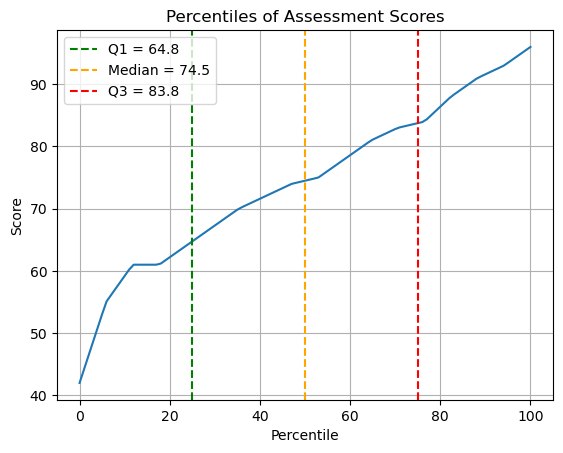

In [ ]:
scores = np.array([42, 55, 61, 61, 64, 67, 70, 72, 74, 75, 78, 81, 83, 84, 88, 91, 93, 96])
percentiles = np.arange(0, 101)
values = np.percentile(scores, percentiles)
q1, median, q3 = np.percentile(scores, [25, 50, 75])

plt.plot(percentiles, values)
plt.axvline(25, color='green', linestyle='--', label='Q1 = ' + str(round(q1, 1)))
plt.axvline(50, color='orange', linestyle='--', label='Median = ' + str(round(median, 1)))
plt.axvline(75, color='red', linestyle='--', label='Q3 = ' + str(round(q3, 1)))
plt.xlabel('Percentile')
plt.ylabel('Score')
plt.title('Percentiles of Assessment Scores')
plt.grid()
plt.legend()
plt.show()


## Question 2. Population and GDP over time

The arrays below contain approximate population and GDP data for a country in selected years. Make a scatter plot with year on the horizontal axis and population on the vertical axis. Use GDP as the marker size and marker colour. Add a colourbar labelled `GDP (trillion US dollars)`.

Calculate the Pearson correlation coefficient between year and population and include it in the title.

Use a marker size such as `s = 40*gdp` to make the GDP values visible. The correlation can be placed in the title by joining the text with `str(r)`, for example `'Correlation = ' + str(r)`.


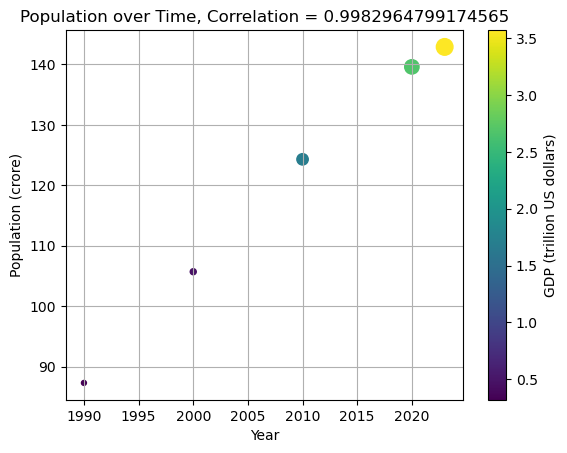

In [29]:
year = np.array([1990, 2000, 2010, 2020, 2023])
population = np.array([87.3, 105.7, 124.3, 139.6, 142.9])
gdp = np.array([0.32, 0.47, 1.68, 2.67, 3.57])

r = np.corrcoef(year, population)[0, 1]
plt.scatter(year, population, s=40*gdp, c=gdp)
plt.colorbar(label='GDP (trillion US dollars)')
plt.xlabel('Year')
plt.ylabel('Population (crore)')
plt.title('Population over Time, Correlation = ' + str(r))
plt.grid()
plt.show()


## Question 3. Relative histograms of cricket scores

Load `data/sachin.txt` and `data/kohli.txt` using `np.loadtxt`. Plot their relative histograms together using `density=True`, the same bins, some transparency, and a legend. Use bins from 0 to 200 in steps of 10. Also draw one vertical dashed line for each player's mean.

To plot both players together, pass the two arrays together to `plt.hist` in the same way that multiple datasets were passed together to `plt.boxplot` in the lecture.


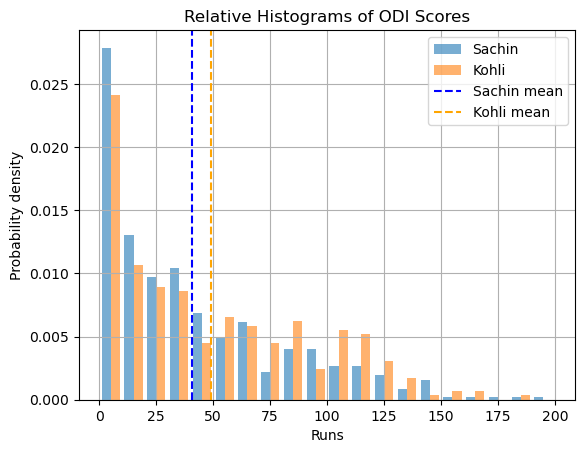

In [5]:
sachin = np.loadtxt('data/sachin.txt')
kohli = np.loadtxt('data/kohli.txt')
bins = range(0, 201, 10)

plt.hist((sachin, kohli), bins=bins, density=True, alpha=0.6, label=['Sachin', 'Kohli'])
plt.axvline(np.mean(sachin), color='blue', linestyle='--', label='Sachin mean')
plt.axvline(np.mean(kohli), color='orange', linestyle='--', label='Kohli mean')
plt.xlabel('Runs')
plt.ylabel('Probability density')
plt.title('Relative Histograms of ODI Scores')
plt.legend()
plt.grid()
plt.show()


## Question 4. PMF and CDF of cricket scores

Load `data/rohit.txt`. Use `np.histogram` with the integer bins `range(301)` and `density=True` to obtain an empirical probability mass function. Use `np.cumsum` to obtain its cumulative distribution function.

Make **two separate plots**, not subplots:

1. Plot score against the PMF.
2. In a new figure, plot score against the CDF.

Label both plots properly. Calculate and print the empirical probability that Rohit scores more than 50.

The score values corresponding to the histogram are `bins[:-1]`. Since the bins have width 1, summing the PMF entries for scores 51 onward gives the required probability.


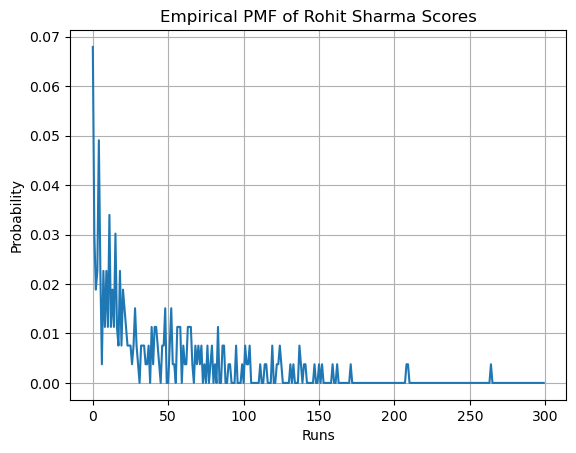

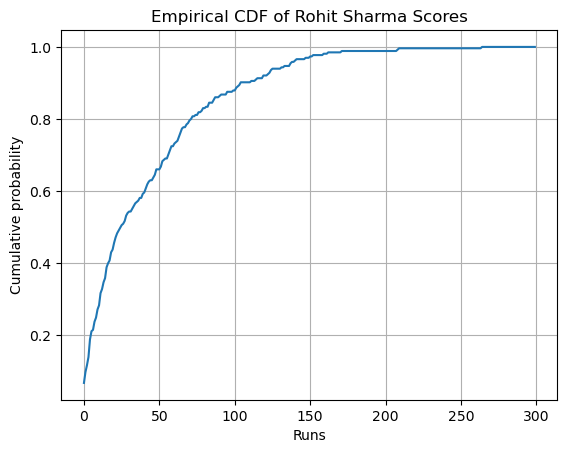

Probability of scoring more than 50: 0.33962264150943394


In [30]:
rohit = np.loadtxt('data/rohit.txt')
pmf, bins = np.histogram(rohit, bins=range(301), density=True)
cdf = np.cumsum(pmf)
scores = bins[:-1]

plt.plot(scores, pmf)
plt.xlabel('Runs')
plt.ylabel('Probability')
plt.title('Empirical PMF of Rohit Sharma Scores')
plt.grid()
plt.show()

plt.figure()
plt.plot(scores, cdf)
plt.xlabel('Runs')
plt.ylabel('Cumulative probability')
plt.title('Empirical CDF of Rohit Sharma Scores')
plt.grid()
plt.show()

probability = np.sum(pmf[51:])
print('Probability of scoring more than 50:', probability)


## Question 5. Comparing cricket players

Load `data/sachin.txt`, `data/kohli.txt` and `data/rohit.txt`.

1. Make one box plot comparing the three players. Show the means and use the player names as labels.
2. Make a separate violin plot comparing the same three players. Use `plt.xticks` to place the player names below the three violins.
3. Write two or three sentences below the plots describing differences you see in their typical scores and spread.

Start with `plt.boxplot((sachin, kohli, rohit), labels=[...], showmeans=True)`. For the second plot, `plt.violinplot((sachin, kohli, rohit), showmeans=True, showmedians=True)` is sufficient; no manual colouring is required.


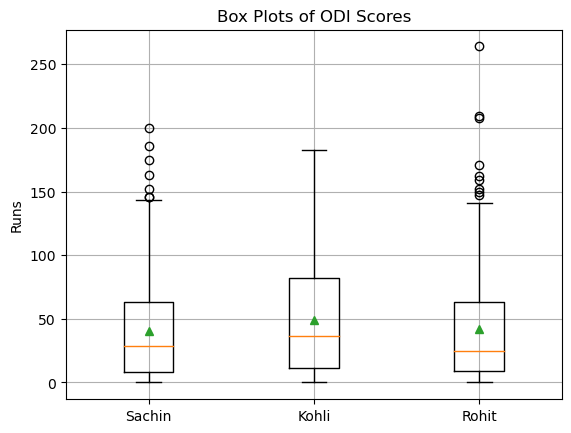

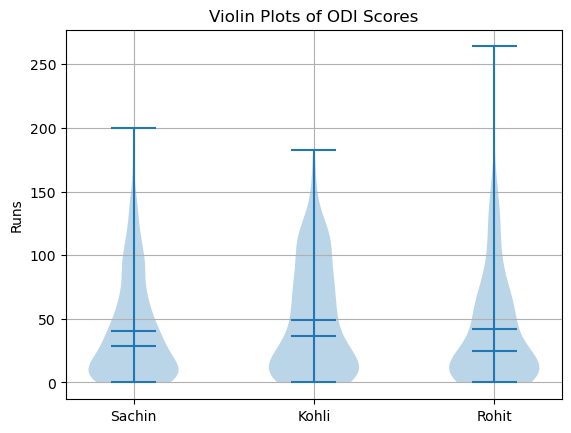

In [32]:
sachin = np.loadtxt('data/sachin.txt')
kohli = np.loadtxt('data/kohli.txt')
rohit = np.loadtxt('data/rohit.txt')

plt.boxplot((sachin, kohli, rohit), labels=['Sachin', 'Kohli', 'Rohit'], showmeans=True)
plt.ylabel('Runs')
plt.title('Box Plots of ODI Scores')
plt.grid()
plt.show()

plt.figure()
plt.violinplot((sachin, kohli, rohit), showmeans=True, showmedians=True)
plt.xticks([1, 2, 3], ['Sachin', 'Kohli', 'Rohit'])
plt.ylabel('Runs')
plt.title('Violin Plots of ODI Scores')
plt.grid()
plt.show()


The median line and the middle of each violin indicate a typical score. The vertical extent and width of the plots show the spread and where scores are concentrated. Exact conclusions should be based on the plots produced from the supplied data.


## Question 6. Bar chart and pie chart

The following data gives the number of cases in six categories.

1. Make a bar chart with the category names on the horizontal axis.
2. Make a separate pie chart using the same data.
3. Which plot makes it easier to compare categories with similar values?

Use only the basic `plt.bar` and `plt.pie` options demonstrated in the lecture.


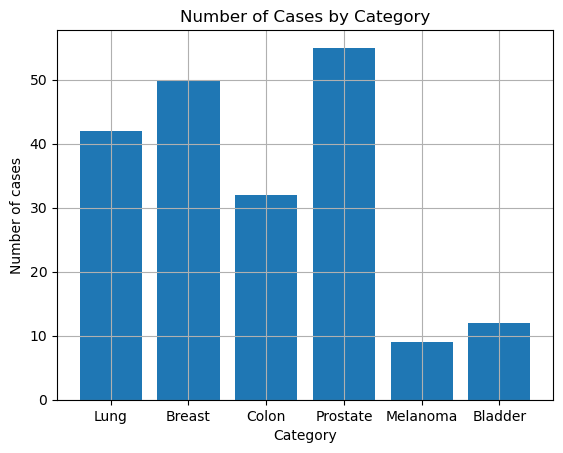

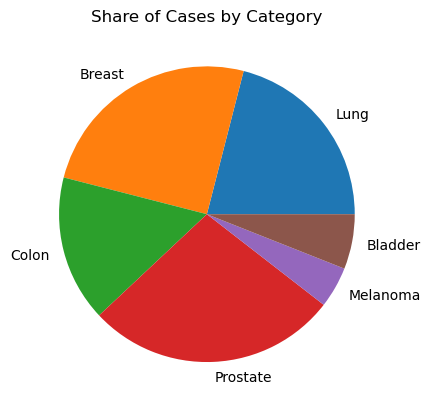

In [8]:
categories = ['Lung', 'Breast', 'Colon', 'Prostate', 'Melanoma', 'Bladder']
numbers = [42, 50, 32, 55, 9, 12]

plt.bar(categories, numbers)
plt.xlabel('Category')
plt.ylabel('Number of cases')
plt.title('Number of Cases by Category')
plt.grid()
plt.show()

plt.figure()
plt.pie(numbers, labels=categories)
plt.title('Share of Cases by Category')
plt.show()


The bar chart makes close comparisons easier because all bars use the same baseline.


## Question 7. Plotting a smiley face

Define a function `smiley()` that plots a smiley face made from:

- a unit circle centred at the origin for the face,
- circles of radius 0.15 centred at $(-0.35,0.35)$ and $(0.35,0.35)$ for the eyes,
- a lower semicircle of radius 0.5, shifted down by 0.05, for the mouth.

Use four simple `plt.plot` calls, one for each part. Use `plt.axis('equal')` so that the circles do not appear stretched.

To construct the coordinates, recall that a circle of radius $r$ centred at $(a,b)$ can be parametrized as

$$
x=a+r\cos\theta,\qquad y=b+r\sin\theta.
$$

A complete circle uses $0\leq\theta\leq2\pi$. Therefore, generate one angle array over this interval for the face and eyes. For the lower semicircular mouth, use the appropriate half of this range, from $\pi$ to $2\pi$.

The constants $a$ and $b$ translate a circle to its required centre. More generally, a translation by $(dx,dy)$ changes $(x,y)$ to $(x+dx,y+dy)$. If you first obtain the wrong semicircle, think about how reflecting its $y$-coordinates across a horizontal line changes its orientation. Plot the four parts separately; there is no need to combine their coordinates into one array.


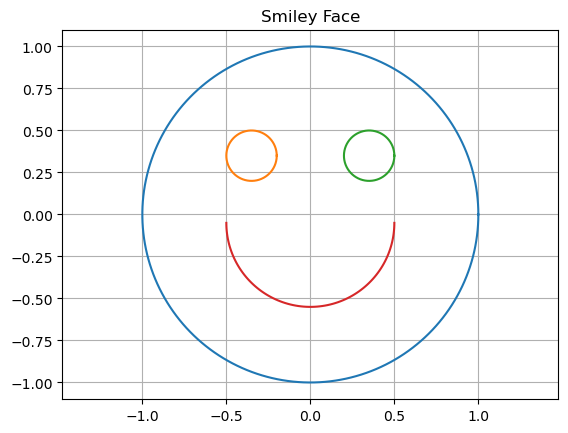

In [9]:
def smiley():
    theta = np.linspace(0, 2*np.pi, 200)
    mouth_theta = np.linspace(np.pi, 2*np.pi, 100)

    plt.plot(np.cos(theta), np.sin(theta))
    plt.plot(0.15*np.cos(theta) - 0.35, 0.15*np.sin(theta) + 0.35)
    plt.plot(0.15*np.cos(theta) + 0.35, 0.15*np.sin(theta) + 0.35)
    plt.plot(0.5*np.cos(mouth_theta), 0.5*np.sin(mouth_theta) - 0.05)
    plt.axis('equal')
    plt.title('Smiley Face')
    plt.grid()
    plt.show()

smiley()


## Question 8. Translating and rotating a polygon

Write the following three functions:

- `ngon(n)`: returns the coordinates of the vertices of a regular unit $n$-gon.
- `translate(x, y, dx, dy)`: translates every point by $(dx,dy)$.
- `rotate(x, y, theta)`: rotates every point anticlockwise about the origin.

For a regular pentagon, plot the original polygon, its translation by $(2,1)$, and its rotation by $\pi/4$ on the same graph. Add a legend and use equal axis scaling.

A regular $n$-gon can be generated by placing $n$ equally spaced points around the unit circle. Use the angles

$$
\theta_k=\frac{2\pi k}{n},\qquad k=0,1,\ldots,n-1,
$$

and take the corresponding cosine and sine values as the $x$- and $y$-coordinates. To make the polygon closed when plotting it, append the first vertex again at the end.

For a point $(x,y)$, anticlockwise rotation by an angle $\theta$ is given directly by

$$
x'=x\cos\theta-y\sin\theta,\qquad
y'=x\sin\theta+y\cos\theta.
$$

Apply these two formulas directly to the coordinate arrays; no matrix construction is needed. Translation is then obtained by adding $dx$ to every $x$-coordinate and $dy$ to every $y$-coordinate. For another explanation of the rotation formulas, see the [rotation matrix reference](https://en.wikipedia.org/wiki/Rotation_matrix).


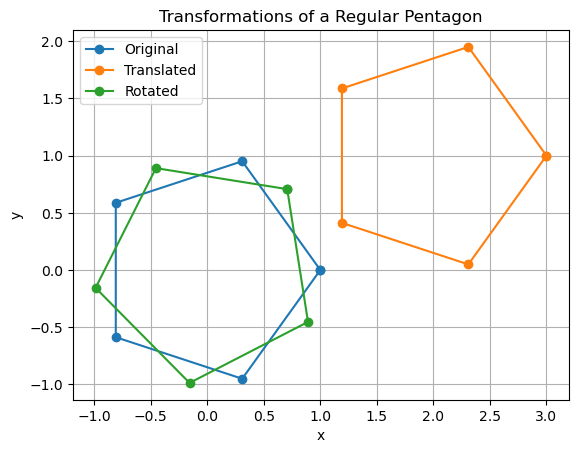

In [25]:
def ngon(n):
    theta = np.linspace(0, 2*np.pi, n, endpoint=False)
    return np.cos(theta), np.sin(theta)

def translate(x, y, dx, dy):
    return x + dx, y + dy

def rotate(x, y, theta):
    x_rotated = x*np.cos(theta) - y*np.sin(theta)
    y_rotated = x*np.sin(theta) + y*np.cos(theta)
    return x_rotated, y_rotated

x, y = ngon(5)
xt, yt = translate(x, y, 2, 1)
xr, yr = rotate(x, y, np.pi/4)

plt.plot(np.append(x, x[0]), np.append(y, y[0]), 'o-', label='Original')
plt.plot(np.append(xt, xt[0]), np.append(yt, yt[0]), 'o-', label='Translated')
plt.plot(np.append(xr, xr[0]), np.append(yr, yr[0]), 'o-', label='Rotated') 
plt.xlabel('x')
plt.ylabel('y')
plt.title('Transformations of a Regular Pentagon')
plt.grid()
plt.legend()
plt.show()


## Question 9. An interactive sine plot

The lecture used `interact` to control a plot. Complete the function below so that it plots

$$y=\sqrt x \sin(kx+\phi), \qquad 0 \leq x \leq 2\pi.$$

Use the decorator `@interact(k=(1, 20), phi=(0.0, 2*np.pi))`. The graph must update when either control changes. Add axis labels, a title and a grid.

**Hint:** First make the function work by calling it normally. Then add the `@interact` line immediately above `def sine_plot(...):`.


In [ ]:
from ipywidgets import interact

@interact(k=(1, 20), phi=(0.0, 2*np.pi))
def sine_plot(k=1, phi=0.0):
    x = np.linspace(0, 2*np.pi, 1000)
    y = np.sqrt(x)*np.sin(k*x + phi)
    plt.plot(x, y)
    plt.xlabel('x')
    plt.ylabel('sin(kx + phi)')
    plt.title('Interactive Sine Plot')
    plt.grid()
    plt.show()

interactive(children=(IntSlider(value=1, description='k', max=20, min=1), FloatSlider(value=0.0, description='…

## Question 10. An interactive cricket histogram

Load the scores of Sachin, Kohli and Rohit. Complete an interactive function `score_histogram(player, bins)` that displays a relative histogram for the selected player.

- The `player` control must offer `Sachin`, `Kohli` and `Rohit`.
- The `bins` slider must run from 5 to 40.
- Use `density=True`, and label the plot.

The starter dictionary maps each displayed name to its data array.

**Hint:** Follow the decorator example from the lecture. Inside the function, obtain the chosen array using `scores[player]`.


In [15]:
from ipywidgets import interact

sachin = np.loadtxt('data/sachin.txt')
kohli = np.loadtxt('data/kohli.txt')
rohit = np.loadtxt('data/rohit.txt')
scores = {'Sachin': sachin, 'Kohli': kohli, 'Rohit': rohit}

@interact(player=['Sachin', 'Kohli', 'Rohit'], bins=(5, 40))
def score_histogram(player='Sachin', bins=10):
    data = scores[player]
    plt.hist(data, bins=bins, density=True)
    plt.xlabel('Runs')
    plt.ylabel('Probability density')
    plt.title(player + ' ODI Score Distribution')
    plt.grid()
    plt.show()


interactive(children=(Dropdown(description='player', options=('Sachin', 'Kohli', 'Rohit'), value='Sachin'), In…